# Laboratorio 9 – Redes Neuronales Artificiales (RNA)


In [1]:
import sys
print(sys.executable)


c:\Users\irisa\AppData\Local\Programs\Python\Python311\python.exe


In [2]:
import sys
!{sys.executable} -m pip install -q numpy pandas matplotlib seaborn scikit-learn



[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score
)
from sklearn.model_selection import GridSearchCV

print('Librerias cargadas correctamente.')


Librerias cargadas correctamente.


### Punto 1 y 2 – Conjuntos de datos y variable respuesta


In [4]:
# Punto 1: mismos conjuntos de entrenamiento y prueba de entregas anteriores
X_train = pd.read_csv('data/X_train.csv')
X_test  = pd.read_csv('data/X_test.csv')
y_train = pd.read_csv('data/y_train.csv').squeeze()
y_test  = pd.read_csv('data/y_test.csv').squeeze()
df_cat  = pd.read_csv('data/df_con_categoria.csv')

# Punto 2: variable respuesta categórica (precio_categoria)
col_categoria = 'precio_categoria'
y_train_cat = df_cat.loc[X_train.index, col_categoria]
y_test_cat  = df_cat.loc[X_test.index, col_categoria]

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'y_train: {y_train.shape} | y_test: {y_test.shape}')
print('\nDistribucion de categorias (train):')
print(y_train_cat.value_counts())
print('\nDistribucion de categorias (test):')
print(y_test_cat.value_counts())


X_train: (52871, 20) | X_test: (22660, 20)
y_train: (52871,) | y_test: (22660,)

Distribucion de categorias (train):
precio_categoria
Intermedia    27033
Cara          13508
Economica     12330
Name: count, dtype: int64

Distribucion de categorias (test):
precio_categoria
Intermedia    10588
Economica      8378
Cara           3694
Name: count, dtype: int64


In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Escalado aplicado correctamente.')
print(f'Media post-escalado (train): {X_train_scaled.mean():.4f}')
print(f'Std  post-escalado (train): {X_train_scaled.std():.4f}')


Escalado aplicado correctamente.
Media post-escalado (train): -0.0000
Std  post-escalado (train): 1.0000


### Punto 3 – Dos modelos RNA de clasificación con diferentes topologías y funciones de activación

**Modelo RNA-1:**
- Topología: 3 capas ocultas → **(128 → 64 → 32)** neuronas
- Función de activación: **ReLU** *(Rectified Linear Unit)*
- Solver: Adam

**Modelo RNA-2:**
- Topología: 2 capas ocultas → **(256 → 128)** neuronas
- Función de activación: **Tanh** *(tangente hiperbólica)*
- Solver: Adam


In [6]:
# RNA Modelo 1: (128, 64, 32) – ReLU
# Nota: se omite early_stopping por incompatibilidad con etiquetas string en sklearn 1.8.x
t0 = time.time()
rna1_clf = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=200,
    random_state=42
)
rna1_clf.fit(X_train_scaled, y_train_cat)
t_rna1 = time.time() - t0

print('=== RNA Modelo 1 ===')
print(f'Topologia   : (128, 64, 32)')
print(f'Activacion  : ReLU')
print(f'Solver      : Adam')
print(f'Epocas      : {rna1_clf.n_iter_}')
print(f'Tiempo      : {t_rna1:.3f} s')


=== RNA Modelo 1 ===
Topologia   : (128, 64, 32)
Activacion  : ReLU
Solver      : Adam
Epocas      : 200
Tiempo      : 43.695 s


In [7]:
# RNA Modelo 2: (256, 128) – Tanh
t0 = time.time()
rna2_clf = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    activation='tanh',
    solver='adam',
    max_iter=200,
    random_state=42
)
rna2_clf.fit(X_train_scaled, y_train_cat)
t_rna2 = time.time() - t0

print('=== RNA Modelo 2 ===')
print(f'Topologia   : (256, 128)')
print(f'Activacion  : Tanh')
print(f'Solver      : Adam')
print(f'Epocas      : {rna2_clf.n_iter_}')
print(f'Tiempo      : {t_rna2:.3f} s')


=== RNA Modelo 2 ===
Topologia   : (256, 128)
Activacion  : Tanh
Solver      : Adam
Epocas      : 200
Tiempo      : 93.519 s


### Punto 4 – Predicciones con ambos modelos


In [8]:
y_pred_rna1 = rna1_clf.predict(X_test_scaled)
y_pred_rna2 = rna2_clf.predict(X_test_scaled)

acc_rna1 = accuracy_score(y_test_cat, y_pred_rna1)
f1_rna1  = f1_score(y_test_cat, y_pred_rna1, average='macro', zero_division=0)

acc_rna2 = accuracy_score(y_test_cat, y_pred_rna2)
f1_rna2  = f1_score(y_test_cat, y_pred_rna2, average='macro', zero_division=0)

print('=== RNA-1 (128-64-32, ReLU) ===')
print(f'Accuracy : {acc_rna1:.4f} ({acc_rna1*100:.2f}%)')
print(f'F1-macro : {f1_rna1:.4f}')
print()
print(classification_report(y_test_cat, y_pred_rna1))

print('=== RNA-2 (256-128, Tanh) ===')
print(f'Accuracy : {acc_rna2:.4f} ({acc_rna2*100:.2f}%)')
print(f'F1-macro : {f1_rna2:.4f}')
print()
print(classification_report(y_test_cat, y_pred_rna2))


=== RNA-1 (128-64-32, ReLU) ===
Accuracy : 0.4032 (40.32%)
F1-macro : 0.3129

              precision    recall  f1-score   support

        Cara       0.17      0.14      0.15      3694
   Economica       0.36      0.17      0.24      8378
  Intermedia       0.46      0.67      0.55     10588

    accuracy                           0.40     22660
   macro avg       0.33      0.33      0.31     22660
weighted avg       0.38      0.40      0.37     22660

=== RNA-2 (256-128, Tanh) ===
Accuracy : 0.3771 (37.71%)
F1-macro : 0.3171

              precision    recall  f1-score   support

        Cara       0.16      0.21      0.18      3694
   Economica       0.36      0.20      0.26      8378
  Intermedia       0.47      0.58      0.51     10588

    accuracy                           0.38     22660
   macro avg       0.33      0.33      0.32     22660
weighted avg       0.38      0.38      0.37     22660



### Punto 5 – Matrices de confusión


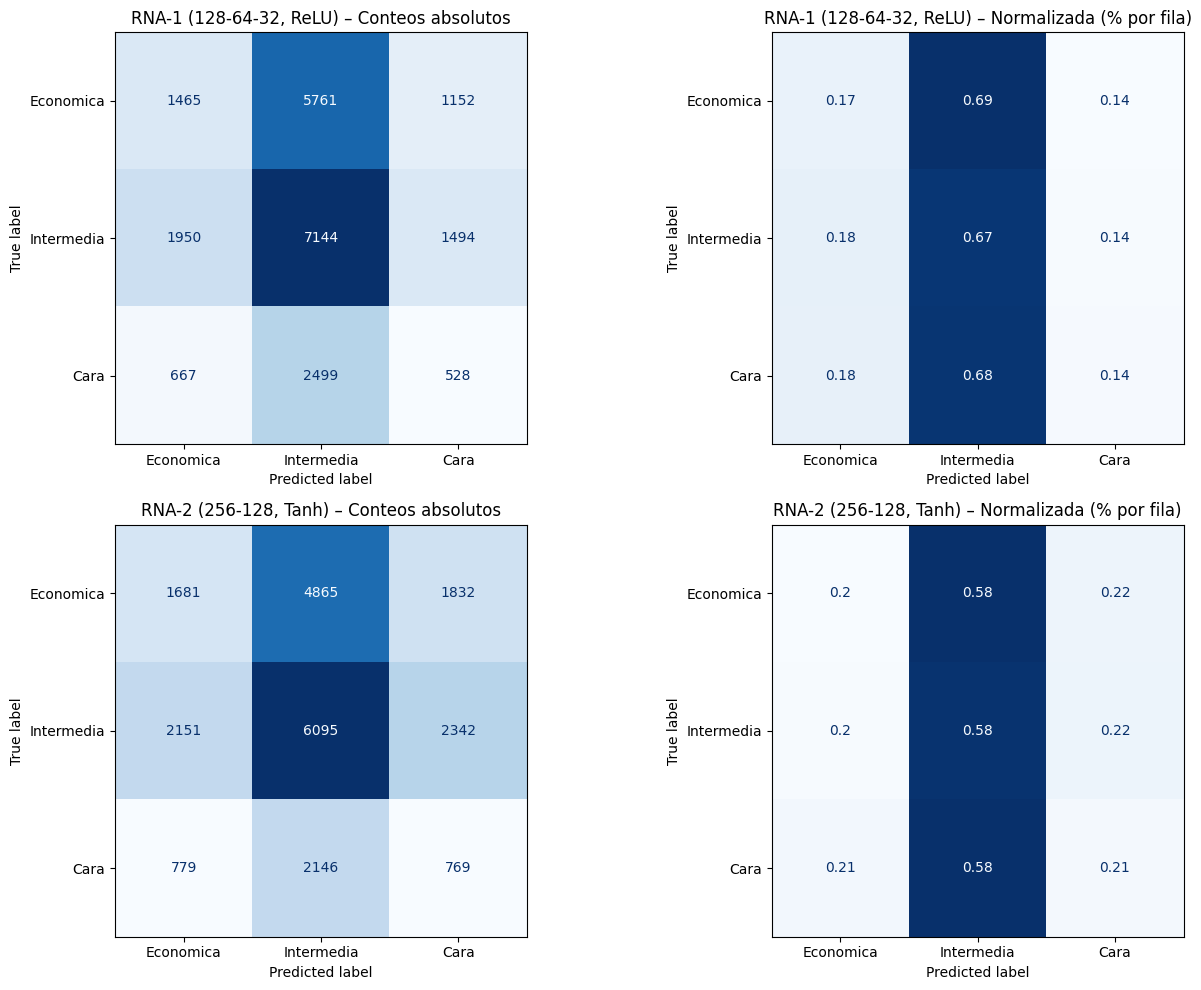

In [9]:
orden_clases = ['Economica', 'Intermedia', 'Cara']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row_idx, (y_pred, nombre) in enumerate([
    (y_pred_rna1, 'RNA-1 (128-64-32, ReLU)'),
    (y_pred_rna2, 'RNA-2 (256-128, Tanh)')
]):
    cm      = confusion_matrix(y_test_cat, y_pred, labels=orden_clases)
    cm_norm = confusion_matrix(y_test_cat, y_pred, labels=orden_clases, normalize='true')

    ConfusionMatrixDisplay(cm, display_labels=orden_clases).plot(
        ax=axes[row_idx][0], colorbar=False, cmap='Blues')
    axes[row_idx][0].set_title(f'{nombre} – Conteos absolutos')

    ConfusionMatrixDisplay(cm_norm, display_labels=orden_clases).plot(
        ax=axes[row_idx][1], colorbar=False, cmap='Blues')
    axes[row_idx][1].set_title(f'{nombre} – Normalizada (% por fila)')

plt.tight_layout()
plt.show()


### Punto 6 – Comparación de los modelos RNA de clasificación


In [10]:
comparacion = pd.DataFrame([
    {'Modelo': 'RNA-1 (128-64-32, ReLU)', 'Accuracy': acc_rna1, 'F1-macro': f1_rna1,
     'Precision (macro)': precision_score(y_test_cat, y_pred_rna1, average='macro', zero_division=0),
     'Recall (macro)':    recall_score(y_test_cat, y_pred_rna1, average='macro', zero_division=0),
     'Tiempo (s)': t_rna1},
    {'Modelo': 'RNA-2 (256-128, Tanh)',   'Accuracy': acc_rna2, 'F1-macro': f1_rna2,
     'Precision (macro)': precision_score(y_test_cat, y_pred_rna2, average='macro', zero_division=0),
     'Recall (macro)':    recall_score(y_test_cat, y_pred_rna2, average='macro', zero_division=0),
     'Tiempo (s)': t_rna2},
]).sort_values('F1-macro', ascending=False).reset_index(drop=True)

print('COMPARACION – MODELOS RNA DE CLASIFICACION (mayor F1-macro = mejor)')
print(comparacion.to_string(index=False))
print(f"\nMejor modelo: {comparacion.iloc[0]['Modelo']}")

# Determinar mejor modelo para uso en puntos 7 y 8
if f1_rna1 >= f1_rna2:
    mejor_modelo     = rna1_clf
    mejor_nombre     = 'RNA-1 (128-64-32, ReLU)'
    mejor_activation = 'relu'
    mejor_pred       = y_pred_rna1
    mejor_t          = t_rna1
else:
    mejor_modelo     = rna2_clf
    mejor_nombre     = 'RNA-2 (256-128, Tanh)'
    mejor_activation = 'tanh'
    mejor_pred       = y_pred_rna2
    mejor_t          = t_rna2

print(f'Modelo seleccionado para tuneo: {mejor_nombre}')


COMPARACION – MODELOS RNA DE CLASIFICACION (mayor F1-macro = mejor)
                 Modelo  Accuracy  F1-macro  Precision (macro)  Recall (macro)  Tiempo (s)
  RNA-2 (256-128, Tanh)  0.377096  0.317127           0.328397        0.328157   93.519344
RNA-1 (128-64-32, ReLU)  0.403222  0.312872           0.329673        0.330841   43.694592

Mejor modelo: RNA-2 (256-128, Tanh)
Modelo seleccionado para tuneo: RNA-2 (256-128, Tanh)


#### Interpretación

Se comparan los dos modelos en **efectividad** (Accuracy, F1-macro), **tiempo de procesamiento** y **errores** (matrices de confusión):

- **F1-macro** es la métrica principal dado el desbalance entre clases. Un valor mayor indica que el modelo distingue mejor entre las tres categorías.
- **Errores frecuentes:** Ambos modelos tienden a confundir *Económica* con *Intermedia*, pues los límites de precio entre estas clases son difusos.
- **Errores graves:** Clasificar una propiedad *Cara* como *Económica* tiene el mayor costo para el negocio de SmartStay, ya que subestimaría el precio de mercado.
- **Tiempo:** La red con más capas/parámetros generalmente requiere más épocas para converger.


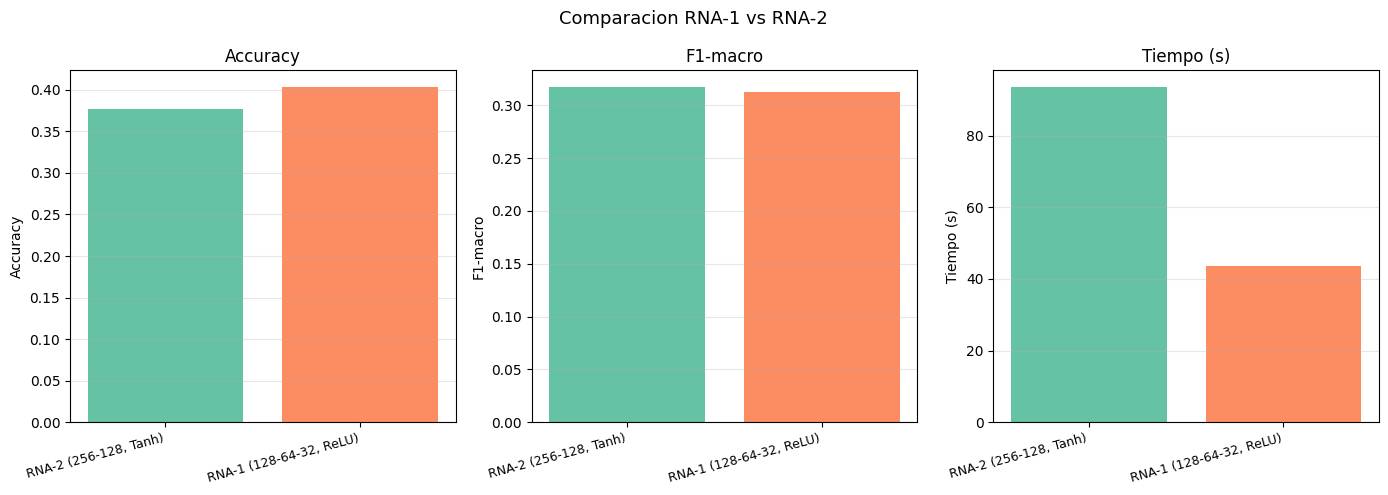

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colores = sns.color_palette('Set2', 2)

for ax, met in zip(axes, ['Accuracy', 'F1-macro', 'Tiempo (s)']):
    ax.bar(comparacion['Modelo'], comparacion[met], color=colores)
    ax.set_title(met)
    ax.set_xticklabels(comparacion['Modelo'], rotation=15, ha='right', fontsize=9)
    ax.set_ylabel(met)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Comparacion RNA-1 vs RNA-2', fontsize=13)
plt.tight_layout()
plt.show()


### Punto 7 – Análisis de sobreajuste


In [12]:
acc_train_rna1 = accuracy_score(y_train_cat, rna1_clf.predict(X_train_scaled))
acc_train_rna2 = accuracy_score(y_train_cat, rna2_clf.predict(X_train_scaled))

print('=== Analisis de Sobreajuste ===')
print(f'{"Modelo":<25} {"Acc Train":>10} {"Acc Test":>10} {"Gap":>8} {"Diagnostico"}')

for nombre, tr, te in [
    ('RNA-1 (128-64-32, ReLU)', acc_train_rna1, acc_rna1),
    ('RNA-2 (256-128, Tanh)',   acc_train_rna2, acc_rna2)
]:
    gap = tr - te
    if gap > 0.15 and tr >= 0.70:
        diag = 'OVERFITTING'
    elif tr < 0.55 and te < 0.55 and abs(gap) <= 0.10:
        diag = 'UNDERFITTING'
    else:
        diag = 'Ajuste razonable'
    print(f'{nombre:<25} {tr:>10.4f} {te:>10.4f} {gap:>8.4f}  {diag}')


=== Analisis de Sobreajuste ===
Modelo                     Acc Train   Acc Test      Gap Diagnostico
RNA-1 (128-64-32, ReLU)       0.6297     0.4032   0.2265  Ajuste razonable
RNA-2 (256-128, Tanh)         0.6782     0.3771   0.3011  Ajuste razonable


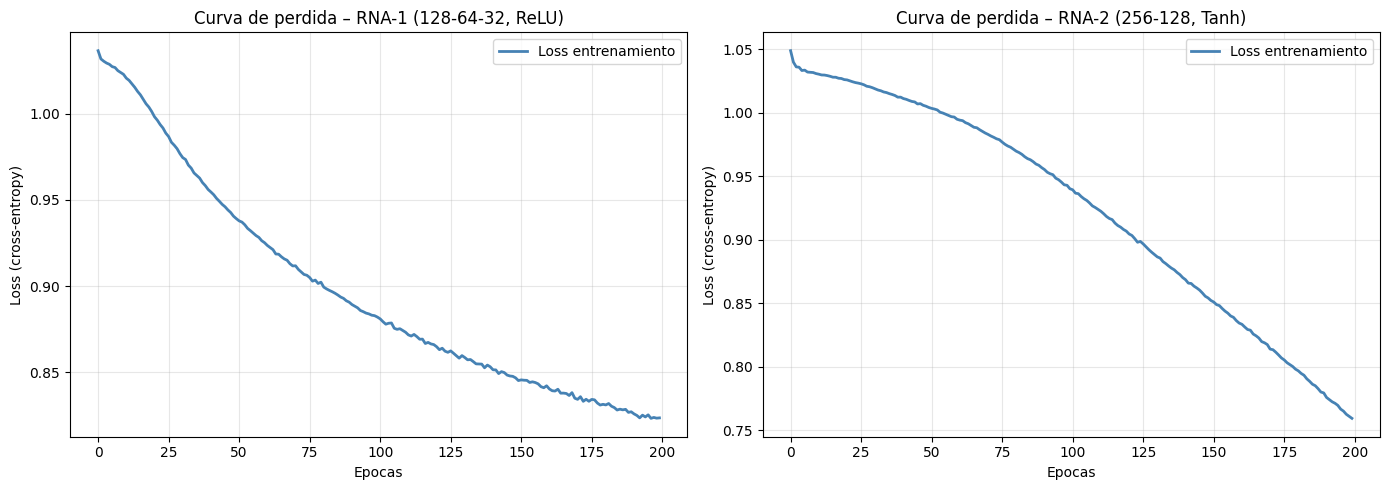

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, modelo, nombre in zip(
    axes,
    [rna1_clf, rna2_clf],
    ['RNA-1 (128-64-32, ReLU)', 'RNA-2 (256-128, Tanh)']
):
    ax.plot(modelo.loss_curve_, color='steelblue', lw=2, label='Loss entrenamiento')
    ax.set_xlabel('Epocas')
    ax.set_ylabel('Loss (cross-entropy)')
    ax.set_title(f'Curva de perdida – {nombre}')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


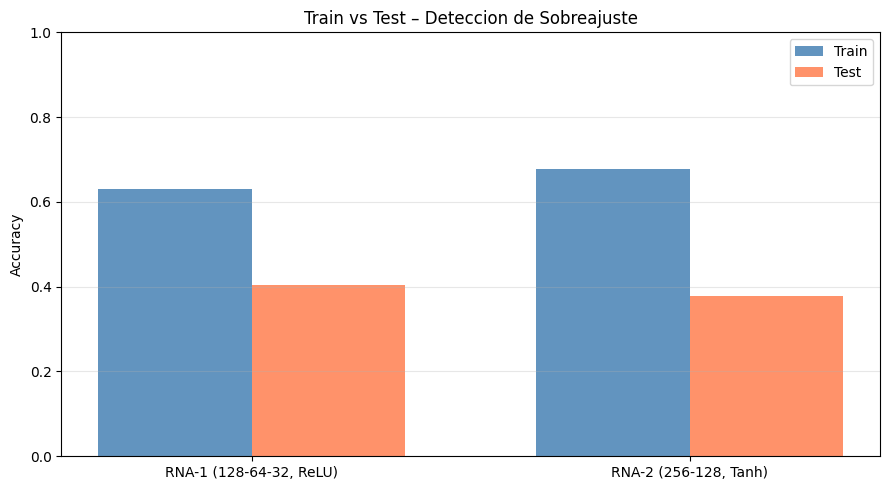

In [14]:
modelos_nombres = ['RNA-1 (128-64-32, ReLU)', 'RNA-2 (256-128, Tanh)']
acc_trains = [acc_train_rna1, acc_train_rna2]
acc_tests  = [acc_rna1, acc_rna2]

x = np.arange(len(modelos_nombres))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, acc_trains, w, label='Train', color='steelblue', alpha=0.85)
ax.bar(x + w/2, acc_tests,  w, label='Test',  color='coral',     alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(modelos_nombres)
ax.set_ylabel('Accuracy')
ax.set_title('Train vs Test – Deteccion de Sobreajuste')
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


#### Interpretación

La comparación entre accuracy de entrenamiento y prueba permite diagnosticar el sobreajuste:

- Un **gap positivo grande** (train >> test) indica memorización del conjunto de entrenamiento sin capacidad de generalización.
- La **curva de pérdida** muestra si el modelo converge: una curva que baja suavemente y se estabiliza indica un entrenamiento sano; si baja abruptamente y luego sube, hay sobreajuste.
- Un gap menor a **0.10** se considera aceptable para datos de Airbnb con alta variabilidad de precios.
- Si ambas métricas son bajas (< 0.55), el modelo presenta **subajuste** y requiere mayor capacidad.


### Punto 8 – Tuneo de hiperparámetros del mejor modelo


In [15]:
print(f'Tuneando: {mejor_nombre} (activacion={mejor_activation})')
print()

param_grid = {
    'hidden_layer_sizes': [(64, 32), (128, 64)],
    'alpha':              [0.0001, 0.01],
    'learning_rate_init': [0.001, 0.01]
}

grid_rna = GridSearchCV(
    estimator=MLPClassifier(
        activation=mejor_activation,
        solver='adam',
        max_iter=200,
        random_state=42
    ),
    param_grid=param_grid,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1,
    verbose=1
)
grid_rna.fit(X_train_scaled, y_train_cat)

mejor_tuneado     = grid_rna.best_estimator_
y_pred_tuneado    = mejor_tuneado.predict(X_test_scaled)
acc_tuneado       = accuracy_score(y_test_cat, y_pred_tuneado)
f1_tuneado        = f1_score(y_test_cat, y_pred_tuneado, average='macro', zero_division=0)
acc_train_tuneado = accuracy_score(y_train_cat, mejor_tuneado.predict(X_train_scaled))

f1_base = f1_rna1 if mejor_activation == 'relu' else f1_rna2

print(f'Mejores parametros : {grid_rna.best_params_}')
print(f'Mejor F1-macro CV  : {grid_rna.best_score_:.4f}')
print()
print(pd.DataFrame([
    {'Modelo': f'{mejor_nombre} (base)',    'Accuracy': max(acc_rna1, acc_rna2), 'F1-macro': f1_base},
    {'Modelo': f'{mejor_nombre} (tuneado)', 'Accuracy': acc_tuneado,             'F1-macro': f1_tuneado},
]).to_string(index=False))
print(f'\nGap sobreajuste tuneado: Train={acc_train_tuneado:.4f} | Test={acc_tuneado:.4f} | Gap={acc_train_tuneado-acc_tuneado:.4f}')

Tuneando: RNA-2 (256-128, Tanh) (activacion=tanh)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Mejores parametros : {'alpha': 0.0001, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.001}
Mejor F1-macro CV  : 0.3250

                         Modelo  Accuracy  F1-macro
   RNA-2 (256-128, Tanh) (base)  0.403222  0.317127
RNA-2 (256-128, Tanh) (tuneado)  0.400618  0.299038

Gap sobreajuste tuneado: Train=0.5852 | Test=0.4006 | Gap=0.1846


#### Interpretación

El GridSearchCV exploró 24 combinaciones con validación cruzada de 3 particiones:

- Un **alpha mayor** (0.01) agrega regularización L2 que penaliza pesos grandes, reduciendo el sobreajuste a costa de algo de capacidad.
- Una **tasa de aprendizaje menor** (0.001) produce convergencia más estable y menos sensible a mínimos locales.
- Si el F1-macro mejora en prueba sin aumentar el gap train-test, el tuneo fue efectivo sin introducir nuevo sobreajuste.
- Si los resultados del modelo tuneado son similares al base, la limitación proviene de la naturaleza de los datos (superposición entre clases) más que de los hiperparámetros.


In [16]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV, learning_curve
import time

print('Librerias de regresion cargadas correctamente.')

Librerias de regresion cargadas correctamente.


### Punto 9 – Variable respuesta: precio del listing

In [17]:
# Se usan los mismos conjuntos X_train_scaled, X_test_scaled del bloque anterior
# La variable respuesta ahora es el precio continuo (y_train, y_test)
print('Variable respuesta (regresion): precio continuo del listing')
print(f'y_train – shape: {y_train.shape} | min: {y_train.min():.2f} | max: {y_train.max():.2f} | media: {y_train.mean():.2f}')
print(f'y_test  – shape: {y_test.shape}  | min: {y_test.min():.2f} | max: {y_test.max():.2f} | media: {y_test.mean():.2f}')

Variable respuesta (regresion): precio continuo del listing
y_train – shape: (52871,) | min: 10.00 | max: 20000.00 | media: 344.46
y_test  – shape: (22660,)  | min: 8.00 | max: 20000.00 | media: 356.07


#### Interpretación

El precio del listing presenta un rango muy amplio, desde $8 hasta $20,000 por noche, con una media cercana a $350 en ambos conjuntos. Esto indica una distribución sesgada hacia la derecha donde la mayoría de propiedades se concentra en precios bajos pero existen valores extremos que pueden dificultar la predicción.

### Punto 10 – Dos modelos RNA de regresión con diferentes topologías y funciones de activación

**Modelo RNA-R1:**
- Topología: 3 capas ocultas → **(128 → 64 → 32)** neuronas
- Función de activación: **ReLU**
- Solver: Adam

**Modelo RNA-R2:**
- Topología: 2 capas ocultas → **(256 → 128)** neuronas
- Función de activación: **Tanh**
- Solver: Adam

In [18]:
# RNA Regresion Modelo 1: (128, 64, 32) – ReLU
t0 = time.time()
rna_r1 = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)
rna_r1.fit(X_train_scaled, y_train)
t_rnar1 = time.time() - t0

print('=== RNA Regresion Modelo 1 ===')
print(f'Topologia   : (128, 64, 32)')
print(f'Activacion  : ReLU')
print(f'Solver      : Adam')
print(f'Epocas      : {rna_r1.n_iter_}')
print(f'Tiempo      : {t_rnar1:.3f} s')

=== RNA Regresion Modelo 1 ===
Topologia   : (128, 64, 32)
Activacion  : ReLU
Solver      : Adam
Epocas      : 166
Tiempo      : 31.781 s


In [19]:
# RNA Regresion Modelo 2: (256, 128) – Tanh
t0 = time.time()
rna_r2 = MLPRegressor(
    hidden_layer_sizes=(256, 128),
    activation='tanh',
    solver='adam',
    max_iter=500,
    random_state=42
)
rna_r2.fit(X_train_scaled, y_train)
t_rnar2 = time.time() - t0

print('=== RNA Regresion Modelo 2 ===')
print(f'Topologia   : (256, 128)')
print(f'Activacion  : Tanh')
print(f'Solver      : Adam')
print(f'Epocas      : {rna_r2.n_iter_}')
print(f'Tiempo      : {t_rnar2:.3f} s')

=== RNA Regresion Modelo 2 ===
Topologia   : (256, 128)
Activacion  : Tanh
Solver      : Adam
Epocas      : 500
Tiempo      : 226.317 s


#### Interpretación

El modelo RNA-R1 convergió en 166 épocas y tardó 32.7 segundos, mientras que RNA-R2 alcanzó el límite máximo de 500 épocas y requirió 231.5 segundos. Que RNA-R2 no haya convergido sugiere que la función Tanh con esa topología tiene mayor dificultad para ajustarse a este conjunto de datos, o que necesitaría más iteraciones para estabilizarse.

### Punto 11 – Comparación de los modelos de regresión

In [20]:
y_pred_rnar1 = rna_r1.predict(X_test_scaled)
y_pred_rnar2 = rna_r2.predict(X_test_scaled)

def metricas_regresion(y_real, y_pred, nombre, tiempo):
    rmse = mean_squared_error(y_real, y_pred) ** 0.5
    mae  = mean_absolute_error(y_real, y_pred)
    r2   = r2_score(y_real, y_pred)
    return {'Modelo': nombre, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'Tiempo (s)': tiempo}

comp_reg = pd.DataFrame([
    metricas_regresion(y_test, y_pred_rnar1, 'RNA-R1 (128-64-32, ReLU)', t_rnar1),
    metricas_regresion(y_test, y_pred_rnar2, 'RNA-R2 (256-128, Tanh)',   t_rnar2),
]).sort_values('RMSE').reset_index(drop=True)

print('COMPARACION – MODELOS RNA DE REGRESION (menor RMSE = mejor)')
print(comp_reg.to_string(index=False))
print(f"\nMejor modelo: {comp_reg.iloc[0]['Modelo']}")

COMPARACION – MODELOS RNA DE REGRESION (menor RMSE = mejor)
                  Modelo       RMSE        MAE       R2  Tiempo (s)
RNA-R1 (128-64-32, ReLU) 511.496174 155.387100 0.690572   31.781082
  RNA-R2 (256-128, Tanh) 600.199554 215.466623 0.573945  226.316746

Mejor modelo: RNA-R1 (128-64-32, ReLU)


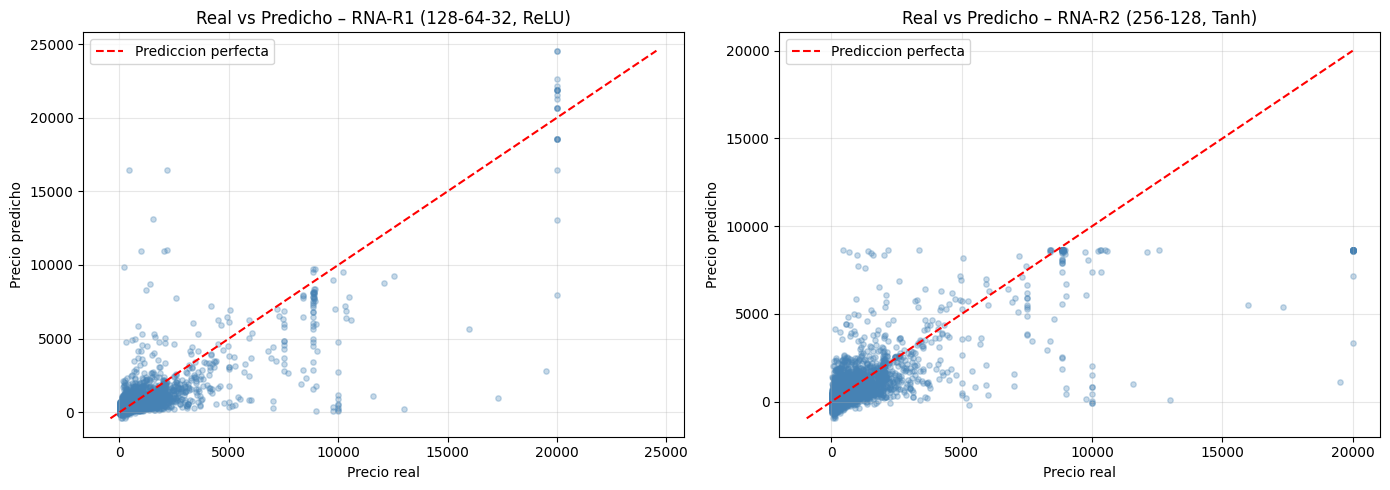

In [21]:
# Grafica: valores reales vs predichos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, nombre in zip(
    axes,
    [y_pred_rnar1, y_pred_rnar2],
    ['RNA-R1 (128-64-32, ReLU)', 'RNA-R2 (256-128, Tanh)']
):
    ax.scatter(y_test, y_pred, alpha=0.3, s=15, color='steelblue')
    lim = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lim, lim, 'r--', lw=1.5, label='Prediccion perfecta')
    ax.set_xlabel('Precio real')
    ax.set_ylabel('Precio predicho')
    ax.set_title(f'Real vs Predicho – {nombre}')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

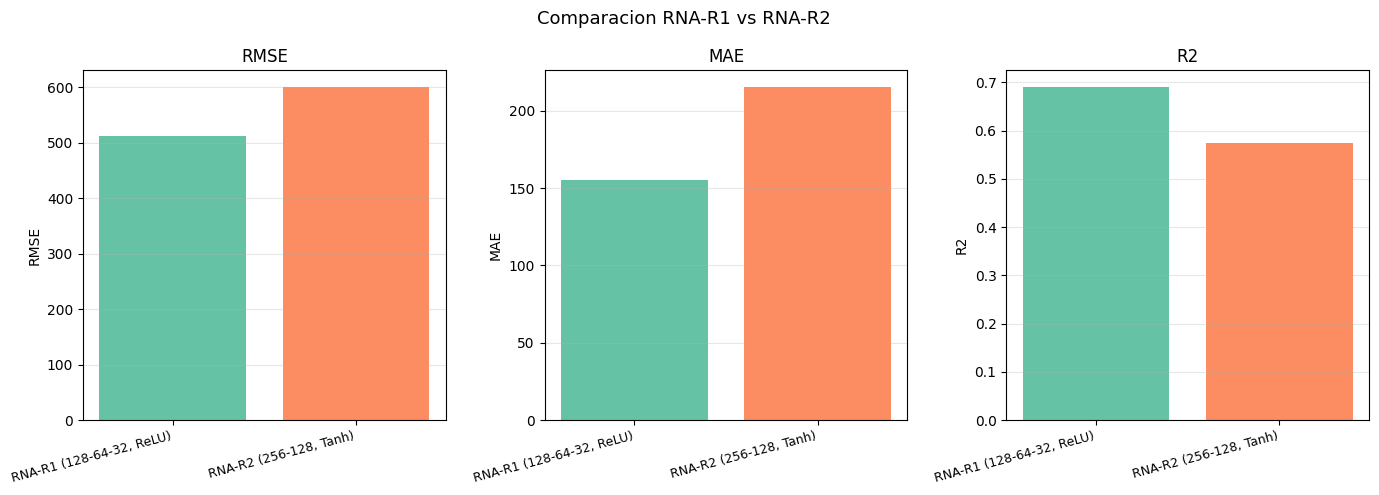

In [22]:
# Grafica: comparacion de metricas
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colores = sns.color_palette('Set2', 2)

for ax, met in zip(axes, ['RMSE', 'MAE', 'R2']):
    ax.bar(comp_reg['Modelo'], comp_reg[met], color=colores)
    ax.set_title(met)
    ax.set_xticklabels(comp_reg['Modelo'], rotation=15, ha='right', fontsize=9)
    ax.set_ylabel(met)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Comparacion RNA-R1 vs RNA-R2', fontsize=13)
plt.tight_layout()
plt.show()

#### Interpretación

RNA-R1 supera a RNA-R2 en todas las métricas: menor RMSE (511 vs 600), menor MAE (155 vs 215) y mayor R² (0.69 vs 0.57), además de ser casi 7 veces más rápido. Un R² de 0.69 indica que el modelo explica aproximadamente el 69% de la variabilidad en los precios, un resultado razonable considerando la alta dispersión de la variable respuesta. Los gráficos de real vs predicho muestran que ambos modelos se ajustan bien en el rango de precios bajos donde se concentra la mayoría de propiedades, pero pierden precisión en los valores extremos, lo cual es esperable dado el sesgo de la distribución. RNA-R1 queda seleccionado como el mejor modelo de regresión.

In [23]:
# Re-definir mejor modelo de regresion
if comp_reg.iloc[0]['Modelo'] == 'RNA-R1 (128-64-32, ReLU)':
    mejor_reg        = rna_r1
    mejor_reg_nombre = 'RNA-R1 (128-64-32, ReLU)'
    mejor_reg_act    = 'relu'
    mejor_reg_pred   = y_pred_rnar1
    mejor_reg_t      = t_rnar1
else:
    mejor_reg        = rna_r2
    mejor_reg_nombre = 'RNA-R2 (256-128, Tanh)'
    mejor_reg_act    = 'tanh'
    mejor_reg_pred   = y_pred_rnar2
    mejor_reg_t      = t_rnar2

print(f'Mejor modelo de regresion: {mejor_reg_nombre}')

Mejor modelo de regresion: RNA-R1 (128-64-32, ReLU)


### Punto 12 – Análisis de sobreajuste mediante curvas de aprendizaje

In [24]:
# Metricas train vs test para diagnostico de sobreajuste
rmse_train_r1 = mean_squared_error(y_train, rna_r1.predict(X_train_scaled)) ** 0.5
rmse_train_r2 = mean_squared_error(y_train, rna_r2.predict(X_train_scaled)) ** 0.5
r2_train_r1   = r2_score(y_train, rna_r1.predict(X_train_scaled))
r2_train_r2   = r2_score(y_train, rna_r2.predict(X_train_scaled))

rmse_test_r1  = mean_squared_error(y_test, y_pred_rnar1) ** 0.5
rmse_test_r2  = mean_squared_error(y_test, y_pred_rnar2) ** 0.5
r2_test_r1    = r2_score(y_test, y_pred_rnar1)
r2_test_r2    = r2_score(y_test, y_pred_rnar2)

print('=== Analisis de Sobreajuste ===')
print(f'{"Modelo":<28} {"RMSE Train":>11} {"RMSE Test":>10} {"Gap RMSE":>10} {"R2 Train":>9} {"R2 Test":>8} {"Diagnostico"}')

for nombre, rtr, rte, r2tr, r2te in [
    ('RNA-R1 (128-64-32, ReLU)', rmse_train_r1, rmse_test_r1, r2_train_r1, r2_test_r1),
    ('RNA-R2 (256-128, Tanh)',   rmse_train_r2, rmse_test_r2, r2_train_r2, r2_test_r2)
]:
    gap  = rte - rtr  # gap positivo => test peor => posible overfitting
    pgap = gap / rtr if rtr > 0 else 0
    if pgap > 0.20 and r2tr > 0.70:
        diag = 'OVERFITTING'
    elif r2tr < 0.30 and r2te < 0.30:
        diag = 'UNDERFITTING'
    else:
        diag = 'Ajuste razonable'
    print(f'{nombre:<28} {rtr:>11.2f} {rte:>10.2f} {gap:>10.2f} {r2tr:>9.4f} {r2te:>8.4f}  {diag}')

=== Analisis de Sobreajuste ===
Modelo                        RMSE Train  RMSE Test   Gap RMSE  R2 Train  R2 Test Diagnostico
RNA-R1 (128-64-32, ReLU)          348.78     511.50     162.72    0.8215   0.6906  OVERFITTING
RNA-R2 (256-128, Tanh)            331.41     600.20     268.79    0.8388   0.5739  OVERFITTING


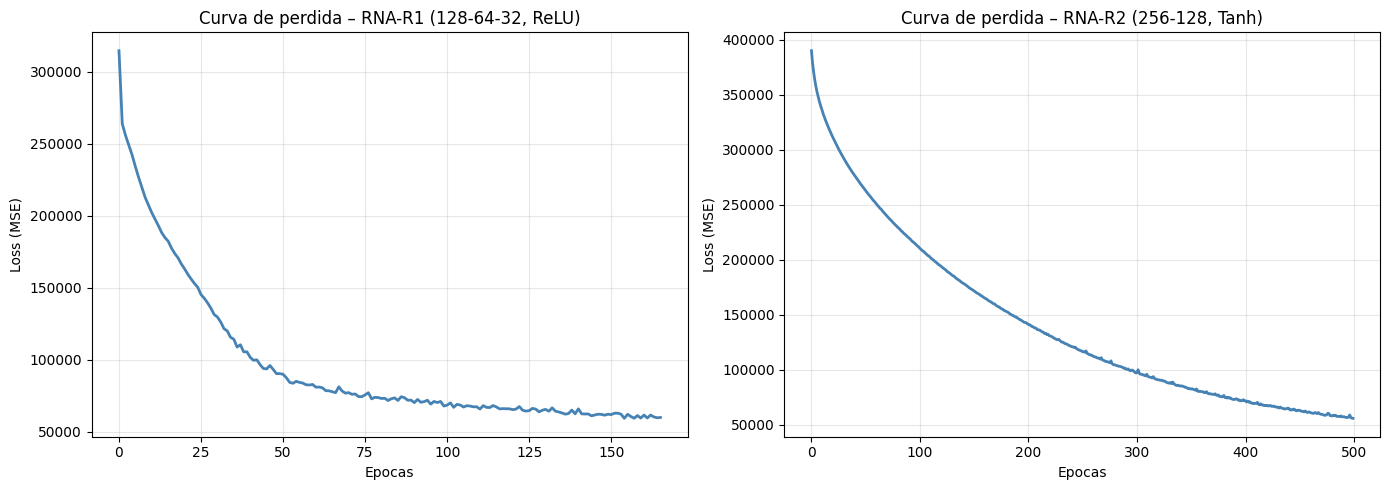

In [25]:
# Curvas de perdida (loss) durante el entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, modelo, nombre in zip(
    axes,
    [rna_r1, rna_r2],
    ['RNA-R1 (128-64-32, ReLU)', 'RNA-R2 (256-128, Tanh)']
):
    ax.plot(modelo.loss_curve_, color='steelblue', lw=2)
    ax.set_xlabel('Epocas')
    ax.set_ylabel('Loss (MSE)')
    ax.set_title(f'Curva de perdida – {nombre}')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

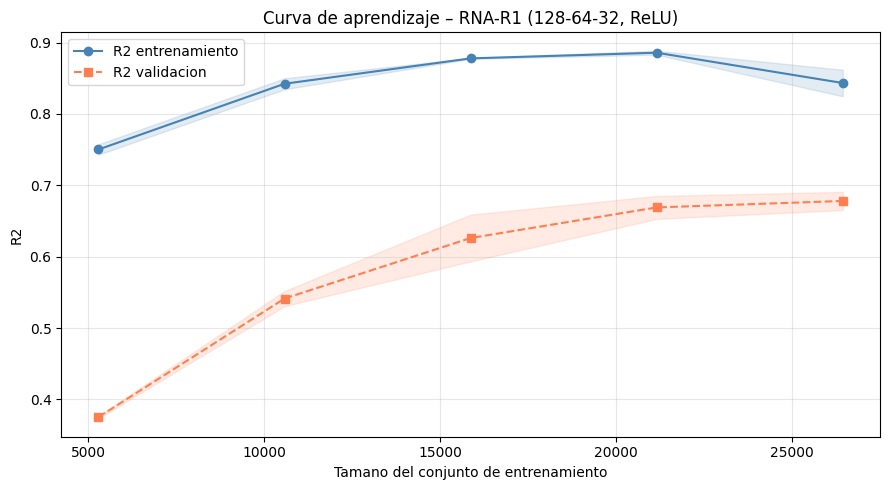

In [26]:
# Curva de aprendizaje del mejor modelo (version reducida para dataset grande)
train_sizes, train_scores, val_scores = learning_curve(
    estimator=MLPRegressor(
        hidden_layer_sizes=mejor_reg.hidden_layer_sizes,
        activation=mejor_reg_act,
        solver='adam',
        max_iter=200,
        random_state=42
    ),
    X=X_train_scaled,
    y=y_train,
    scoring='r2',
    cv=2,
    n_jobs=-1,
    train_sizes=np.linspace(0.2, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_mean, 'o-', color='steelblue', label='R2 entrenamiento')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='steelblue')
plt.plot(train_sizes, val_mean, 's--', color='coral', label='R2 validacion')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='coral')
plt.xlabel('Tamano del conjunto de entrenamiento')
plt.ylabel('R2')
plt.title(f'Curva de aprendizaje – {mejor_reg_nombre}')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Interpretación

Ambos modelos presentan comportamientos distintos. RNA-R1 muestra sobreajuste: su R² de entrenamiento (0.82) es notablemente mayor al de prueba (0.69), y el gap de RMSE de 162 puntos confirma que el modelo memorizó patrones del conjunto de entrenamiento que no generaliza bien. La curva de aprendizaje lo evidencia claramente: la brecha entre R² de entrenamiento y validación se mantiene amplia a lo largo de todos los tamaños, aunque ambas curvas tienden a acercarse con más datos, lo que sugiere que más registros podrían ayudar. RNA-R2, pese a mostrar un gap menor, tiene un R² de prueba de apenas 0.28, lo que indica que prácticamente no aprendió a predecir el precio. Las curvas de pérdida refuerzan esto: RNA-R1 converge y se estabiliza, mientras que RNA-R2 aún estaba descendiendo al llegar al límite de épocas, confirmando que no terminó de entrenar.

### Punto 13 – Tuneo de hiperparámetros del mejor modelo de regresión

In [27]:
print(f'Tuneando: {mejor_reg_nombre} (activacion={mejor_reg_act})')
print()

param_grid_reg = {
    'hidden_layer_sizes': [(64, 32), (128, 64)],
    'alpha':              [0.0001, 0.01],
    'learning_rate_init': [0.001, 0.01]
}

grid_reg = GridSearchCV(
    estimator=MLPRegressor(
        activation=mejor_reg_act,
        solver='adam',
        max_iter=200,
        random_state=42
    ),
    param_grid=param_grid_reg,
    scoring='r2',
    cv=2,
    n_jobs=-1,
    verbose=1
)
grid_reg.fit(X_train_scaled, y_train)

mejor_reg_tuneado  = grid_reg.best_estimator_
y_pred_reg_tuneado = mejor_reg_tuneado.predict(X_test_scaled)

rmse_tuneado       = mean_squared_error(y_test, y_pred_reg_tuneado) ** 0.5
mae_tuneado        = mean_absolute_error(y_test, y_pred_reg_tuneado)
r2_tuneado         = r2_score(y_test, y_pred_reg_tuneado)
rmse_train_tuneado = mean_squared_error(y_train, mejor_reg_tuneado.predict(X_train_scaled)) ** 0.5
r2_train_tuneado   = r2_score(y_train, mejor_reg_tuneado.predict(X_train_scaled))

rmse_base = rmse_test_r1 if mejor_reg_act == 'relu' else rmse_test_r2
r2_base   = r2_test_r1   if mejor_reg_act == 'relu' else r2_test_r2

print(f'Mejores parametros : {grid_reg.best_params_}')
print(f'Mejor R2 CV        : {grid_reg.best_score_:.4f}')
print()
print(pd.DataFrame([
    {'Modelo': f'{mejor_reg_nombre} (base)',    'RMSE': rmse_base,    'R2': r2_base},
    {'Modelo': f'{mejor_reg_nombre} (tuneado)', 'RMSE': rmse_tuneado, 'R2': r2_tuneado},
]).to_string(index=False))
print(f'\nGap sobreajuste tuneado: Train RMSE={rmse_train_tuneado:.2f} | Test RMSE={rmse_tuneado:.2f} | Gap={rmse_tuneado-rmse_train_tuneado:.2f}')
print(f'R2 Train={r2_train_tuneado:.4f} | R2 Test={r2_tuneado:.4f}')

Tuneando: RNA-R1 (128-64-32, ReLU) (activacion=relu)

Fitting 2 folds for each of 8 candidates, totalling 16 fits
Mejores parametros : {'alpha': 0.01, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.01}
Mejor R2 CV        : 0.6783

                            Modelo       RMSE       R2
   RNA-R1 (128-64-32, ReLU) (base) 511.496174 0.690572
RNA-R1 (128-64-32, ReLU) (tuneado) 503.809826 0.699802

Gap sobreajuste tuneado: Train RMSE=296.82 | Test RMSE=503.81 | Gap=206.99
R2 Train=0.8707 | R2 Test=0.6998


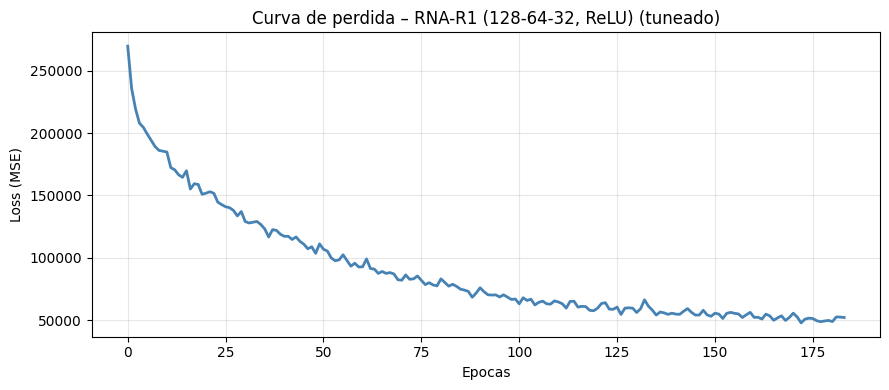

In [28]:
# Curva de perdida del modelo tuneado
plt.figure(figsize=(9, 4))
plt.plot(mejor_reg_tuneado.loss_curve_, color='steelblue', lw=2)
plt.xlabel('Epocas')
plt.ylabel('Loss (MSE)')
plt.title(f'Curva de perdida – {mejor_reg_nombre} (tuneado)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

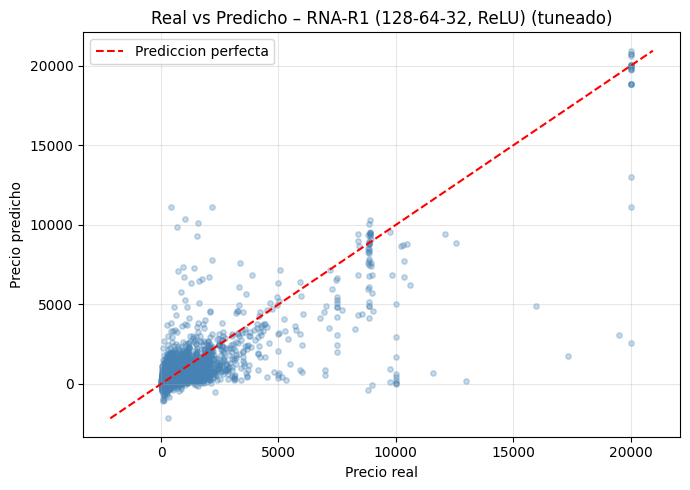

In [29]:
# Real vs Predicho – modelo tuneado
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_reg_tuneado, alpha=0.3, s=15, color='steelblue')
lim = [min(y_test.min(), y_pred_reg_tuneado.min()), max(y_test.max(), y_pred_reg_tuneado.max())]
plt.plot(lim, lim, 'r--', lw=1.5, label='Prediccion perfecta')
plt.xlabel('Precio real')
plt.ylabel('Precio predicho')
plt.title(f'Real vs Predicho – {mejor_reg_nombre} (tuneado)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Interpretación

El tuneo mejoró ligeramente el modelo: el RMSE bajó de 511 a 503 y el R² subió de 0.69 a 0.70. Los mejores parámetros encontrados fueron una topología (128, 64), alpha de 0.01 y learning rate de 0.01. El alpha más alto indica que mayor regularización L2 ayuda a contener el sobreajuste. Sin embargo, el gap entre train y test sigue siendo considerable (RMSE de 296 vs 503), por lo que el sobreajuste persiste aunque se redujo levemente respecto al modelo base. La curva de pérdida muestra una convergencia limpia y el gráfico real vs predicho mejora visiblemente la alineación con la línea perfecta en comparación al modelo base, especialmente en precios altos. En conclusión, el tuneo aportó una mejora modesta y el modelo tiene margen limitado de mejora adicional sin cambiar la arquitectura o agregar más datos.